<a href="https://colab.research.google.com/github/PathakDeepak/TensorFlow_Practise/blob/main/Week_27_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><font color="brown" size="6"><b>Week 27: Graded Mini Project</b></font></center>

**Project title**: Benchmarking RNNs and Transformers for Text Classification

**Objective**: Benchmark and compare Simple RNN and BiLSTM models trained from
scratch with a pretrained Hugging Face Transformer, applied to either IMDb sentiment
analysis (binary) or AG News classification (4-class). Measure and interpret accuracy, F1-
score, speed, and generalization capability.

## <font color="brown">Task 1: Dataset & Splits</font>

### <font color="orange">A. Load the Dataset</font>

In [17]:
import tensorflow_datasets as tfds
import pandas as pd
import numpy as np

splits = ["train[:80%]", "train[80%:]", "test"]
DATASET_NAME = "imdb_reviews"

(ds_train, ds_val, ds_test), ds_info = tfds.load(
    DATASET_NAME,
    split=splits,
    as_supervised=True,
    with_info=True
)

print(ds_info)

tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='/root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0',
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
    supervised_keys=('text', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_e

In [18]:
def ds_to_dataframe(ds, sample_size=5000):
    texts, labels = [], []
    for text, label in tfds.as_numpy(ds.take(sample_size)):
        texts.append(text.decode("utf-8"))
        labels.append(label)
    return pd.DataFrame({"text": texts, "label": labels})

df_sample = ds_to_dataframe(ds_train)
df_sample.head()

df_sample.info()
df_sample.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


,label
count,5000.000000
mean,0.505200
std,0.500023
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


## <font color="brown">Task 2: Model Implementations (from scratch)</font>

In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000
MAX_LEN = 200

def extract_data(ds):
    texts, labels = [], []
    for text, label in tfds.as_numpy(ds):
        texts.append(text.decode("utf-8"))
        labels.append(label)
    return texts, np.array(labels).reshape(-1,1)

train_texts, train_labels = extract_data(ds_train)
val_texts, val_labels = extract_data(ds_val)
test_texts, test_labels = extract_data(ds_test)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train = pad_sequences(tokenizer.texts_to_sequences(train_texts), maxlen=MAX_LEN)
X_val   = pad_sequences(tokenizer.texts_to_sequences(val_texts), maxlen=MAX_LEN)
X_test  = pad_sequences(tokenizer.texts_to_sequences(test_texts), maxlen=MAX_LEN)

### <font color="orange">A. Simple RNN: Embedding → SimpleRNN → Dropout → Dense(logits).</font>

In [20]:
from tensorflow.keras import layers, models

def build_simple_rnn():
    return models.Sequential([
        layers.Embedding(VOCAB_SIZE, 128),
        layers.SimpleRNN(64),
        layers.Dropout(0.5),
        layers.Dense(1)
    ])

simple_rnn = build_simple_rnn()
simple_rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### <font color="orange">B. BiLSTM: Embedding → Bidirectional(LSTM) → Dropout → Dense(logits).</font>

In [21]:
def build_bilstm():
    return models.Sequential([
        layers.Embedding(VOCAB_SIZE, 128),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dropout(0.5),
        layers.Dense(1)
    ])

bilstm = build_bilstm()
bilstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## <font color="brown">Task 3a: Training (scratch models)</font>

In [22]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2)
]

# Simple RNN
simple_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=loss_fn,
    metrics=["accuracy"]
)

history_rnn = simple_rnn.fit(
    X_train, train_labels,
    validation_data=(X_val, val_labels),
    epochs=10,
    batch_size=64,
    callbacks=callbacks
)

# BiLSTM
bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=loss_fn,
    metrics=["accuracy"]
)

history_bilstm = bilstm.fit(
    X_train, train_labels,
    validation_data=(X_val, val_labels),
    epochs=10,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.5821 - loss: 0.6451 - val_accuracy: 0.8028 - val_loss: 0.4375 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8402 - loss: 0.3677 - val_accuracy: 0.8126 - val_loss: 0.4502 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9013 - loss: 0.2461 - val_accuracy: 0.7842 - val_loss: 0.5147 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9663 - loss: 0.0981 - val_accuracy: 0.8076 - val_loss: 0.5104 - learning_rate: 1.0000e-04
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6563 - loss: 0.5592 - val_accuracy: 0.8518 - val_loss: 0.3353 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8916 - loss: 0.2679 - val_accuracy: 0.8650 - val_loss: 0.3228 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9303 - lo

## <font color="brown">Task 3b: Evaluation (scratch models)</font>

In [23]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def evaluate_model(model):
    logits = model.predict(X_test)
    preds = (tf.sigmoid(logits).numpy() > 0.5).astype(int)
    acc = accuracy_score(test_labels, preds)
    f1  = f1_score(test_labels, preds)
    cm  = confusion_matrix(test_labels, preds)
    return acc, f1, cm

rnn_acc, rnn_f1, rnn_cm = evaluate_model(simple_rnn)
bilstm_acc, bilstm_f1, bilstm_cm = evaluate_model(bilstm)

print("Simple RNN:", rnn_acc, rnn_f1)
print("BiLSTM:", bilstm_acc, bilstm_f1)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step
Simple RNN: 0.80056 0.8107348921955664
BiLSTM: 0.85644 0.8594037685587809


### <font color="orange">Plot training/validation loss & accuracy curves.</font>

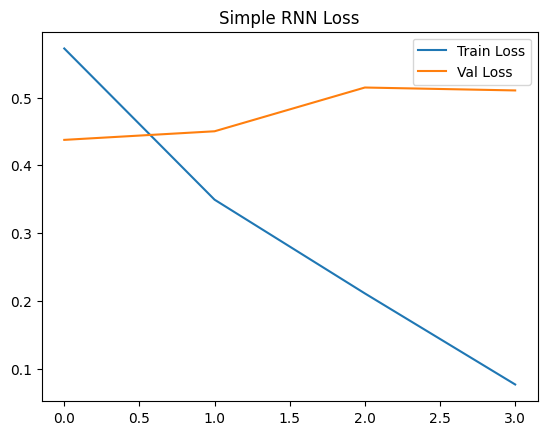

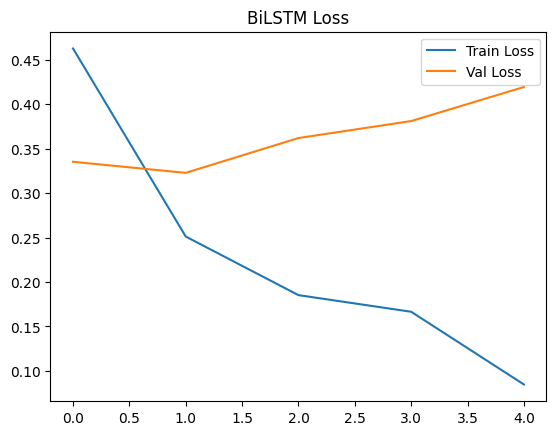

In [24]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure()
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title(title)
    plt.show()

plot_history(history_rnn, "Simple RNN Loss")
plot_history(history_bilstm, "BiLSTM Loss")

## <font color="brown">Task 4: Hugging Face Transformer (inference-only)</font>

In [25]:
!pip install -q transformers torch

In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch, time

model_name = "textattack/bert-base-uncased-imdb"

tokenizer_hf = AutoTokenizer.from_pretrained(model_name)
model_hf = AutoModelForSequenceClassification.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model_hf.to(device)
model_hf.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [27]:
def transformer_inference(texts, batch_size=128):
    all_preds = []
    start = time.time()

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encodings = tokenizer_hf(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors="pt"
        )

        encodings = {k: v.to(device) for k, v in encodings.items()}

        with torch.no_grad():
            outputs = model_hf(**encodings)

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

    end = time.time()
    return np.array(all_preds), end - start

In [28]:
preds_hf, inference_time = transformer_inference(test_texts)

hf_acc = accuracy_score(test_labels.flatten(), preds_hf)
hf_f1  = f1_score(test_labels.flatten(), preds_hf)

print("Transformer:", hf_acc, hf_f1)
print("Inference Time:", inference_time)

Transformer: 0.89088 0.8913407153668446
Inference Time: 249.5583357810974


## <font color="brown">Task 5: Comparison & Analysis</font>

In [29]:
results = pd.DataFrame({
    "Model": ["Simple RNN", "BiLSTM", "BERT"],
    "Test Accuracy": [rnn_acc, bilstm_acc, hf_acc],
    "F1 Score": [rnn_f1, bilstm_f1, hf_f1]
})

results

,Model,Test Accuracy,F1 Score
0,Simple RNN,0.80056,0.810735
1,BiLSTM,0.85644,0.859404
2,BERT,0.89088,0.891341


### <font color="orange">Conclusion</font>

- Transformer (BERT) performs best because it is pretrained on large text corpora and already understands general language patterns.
- RNN and BiLSTM were trained from scratch, so they learned only from the IMDb dataset, which limits their performance.
- BiLSTM performs better than Simple RNN because it captures context from both directions.
- The Transformer uses self-attention, which models long-range relationships better than sequential RNN processing.
- In terms of data efficiency, the Transformer benefits from prior knowledge (transfer learning), while RNN models need more task-specific data.
- However, the Transformer has higher computational cost and latency, especially without GPU.
- RNN and BiLSTM are faster and lighter, making them more suitable for low-resource or real-time deployment.

Overall, the results show a trade-off between higher accuracy (Transformer) and faster inference (RNN/BiLSTM).

## <font color="brown">Task 6: Reproducibility</font>

In [30]:
import random, sys, transformers

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Device:", device)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow: 2.19.0
PyTorch: 2.10.0+cu128
Transformers: 5.0.0
Device: cuda
